In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
GITHUB_TOKEN = secrets.get_secret("GITHUB_TOKEN")
os.system(f'git clone https://{GITHUB_TOKEN}@github.com/m-j-r-q/Cura.git /kaggle/working/Cura')
sys.path.append('/kaggle/working/Cura/backend/src')

IMAGE_DIR = '/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/images-224/images-224'
DATA_DIR  = '/kaggle/input/datasets/junaidrasul/cura-metadata'

print("Setup complete.")

Cloning into '/kaggle/working/Cura'...


Setup complete.


In [3]:
import random

all_images = list(Path(IMAGE_DIR).glob('*.png'))
sample     = random.sample(all_images, 500)

print(f"Total images available: {len(all_images)}")
print(f"Sampled: {len(sample)}")

Total images available: 112120
Sampled: 500


In [4]:
from quality import detect_blur, detect_contrast_and_exposure, detect_rotation

print("Quality functions loaded.")

Quality functions loaded.


In [5]:
records = []

for i, path in enumerate(sample):
    try:
        img  = Image.open(path)
        gray = np.array(img.convert('L'))
        
        blur_score,  _  = detect_blur(gray)
        contrast_score, mean_brightness, _, _, _ = detect_contrast_and_exposure(gray)
        rotation_angle, _ = detect_rotation(gray)
        
        records.append({
            'file':            path.name,
            'blur_score':      blur_score,
            'contrast_score':  contrast_score,
            'mean_brightness': mean_brightness,
            'rotation_angle':  rotation_angle,
        })
    except Exception as e:
        print(f"Skipped {path.name}: {e}")
    
    if (i + 1) % 100 == 0:
        print(f"Processed {i+1}/500")

df = pd.DataFrame(records)
print(f"\nSuccessfully processed: {len(df)} images")
print(df.describe().round(2))

Processed 100/500
Processed 200/500
Processed 300/500
Processed 400/500
Processed 500/500

Successfully processed: 500 images
       blur_score  contrast_score  mean_brightness  rotation_angle
count      500.00          500.00           500.00          500.00
mean       158.40           62.53           136.21            7.57
std        103.72            9.40            25.29           16.66
min         23.13           39.41            47.38            0.00
25%         88.26           55.73           118.87            0.00
50%        129.16           63.72           133.47            0.00
75%        189.41           69.62           155.29            0.00
max        677.49           90.83           208.23           45.00


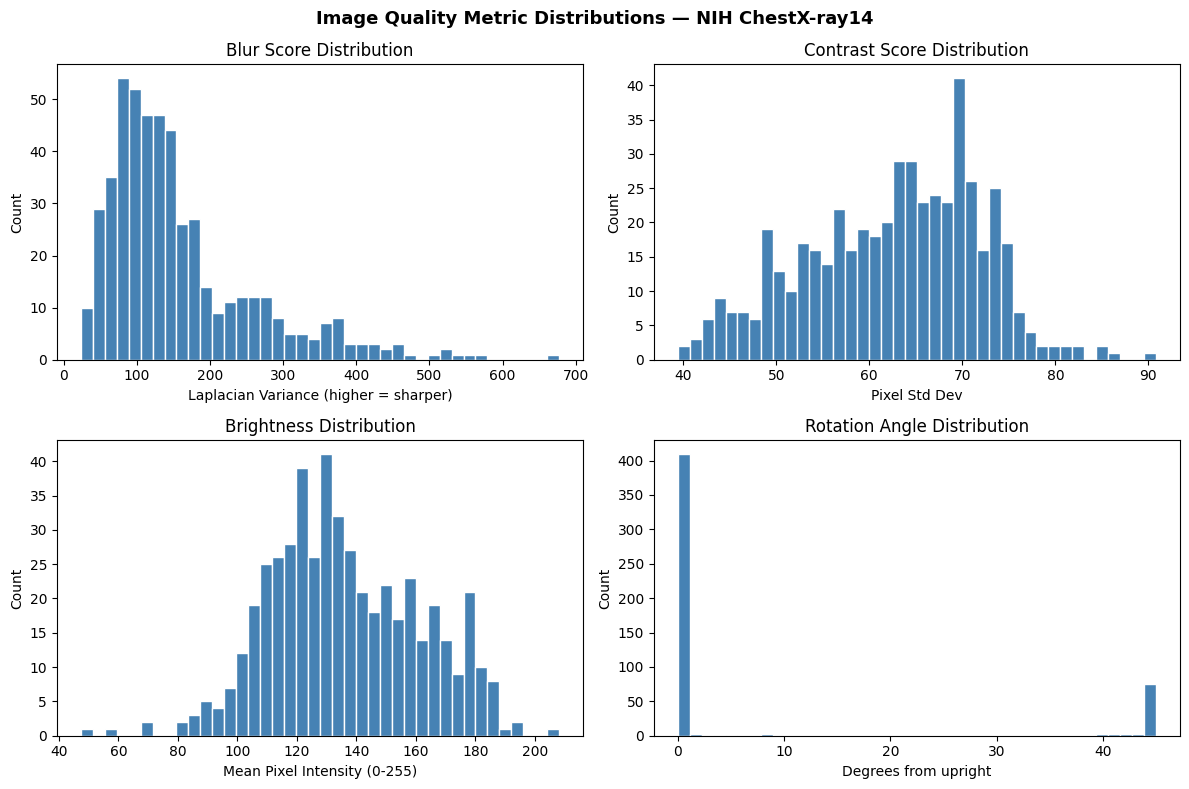

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(df['blur_score'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Blur Score Distribution')
axes[0,0].set_xlabel('Laplacian Variance (higher = sharper)')
axes[0,0].set_ylabel('Count')

axes[0,1].hist(df['contrast_score'], bins=40, color='steelblue', edgecolor='white')
axes[0,1].set_title('Contrast Score Distribution')
axes[0,1].set_xlabel('Pixel Std Dev')
axes[0,1].set_ylabel('Count')

axes[1,0].hist(df['mean_brightness'], bins=40, color='steelblue', edgecolor='white')
axes[1,0].set_title('Brightness Distribution')
axes[1,0].set_xlabel('Mean Pixel Intensity (0-255)')
axes[1,0].set_ylabel('Count')

axes[1,1].hist(df['rotation_angle'], bins=40, color='steelblue', edgecolor='white')
axes[1,1].set_title('Rotation Angle Distribution')
axes[1,1].set_xlabel('Degrees from upright')
axes[1,1].set_ylabel('Count')

plt.suptitle('Image Quality Metric Distributions — NIH ChestX-ray14', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/quality_distributions.png', dpi=150)
plt.show()

In [10]:
percentiles = [1, 2, 5, 10, 25, 98]

thresholds = {}

for metric in ['blur_score', 'contrast_score', 'mean_brightness', 'rotation_angle']:
    print(f"\n{metric}:")
    print(f"  mean:   {df[metric].mean():.2f}")
    print(f"  std:    {df[metric].std():.2f}")
    print(f"  min:    {df[metric].min():.2f}")
    print(f"  max:    {df[metric].max():.2f}")
    for p in percentiles:
        val = np.percentile(df[metric], p)
        print(f"  {p:2d}th percentile: {val:.2f}")
    thresholds[metric] = {p: round(np.percentile(df[metric], p), 2) for p in percentiles}

print("\n--- Suggested thresholds at 2nd percentile ---")
print(f"BLUR_THRESHOLD:       {thresholds['blur_score'][2]}")
print(f"CONTRAST_THRESHOLD:   {thresholds['contrast_score'][2]}")
print(f"BRIGHTNESS_LOW:       {thresholds['mean_brightness'][2]}")
print(f"BRIGHTNESS_HIGH:      {thresholds['mean_brightness'][98] if 98 in thresholds['mean_brightness'] else 'compute separately'}")
print(f"ROTATION_THRESHOLD:   {thresholds['rotation_angle'][98]}")


blur_score:
  mean:   158.40
  std:    103.72
  min:    23.13
  max:    677.49
   1th percentile: 34.71
   2th percentile: 39.57
   5th percentile: 48.79
  10th percentile: 61.44
  25th percentile: 88.26
  98th percentile: 450.65

contrast_score:
  mean:   62.53
  std:    9.40
  min:    39.41
  max:    90.83
   1th percentile: 42.33
   2th percentile: 43.26
   5th percentile: 45.25
  10th percentile: 48.82
  25th percentile: 55.73
  98th percentile: 78.88

mean_brightness:
  mean:   136.21
  std:    25.29
  min:    47.38
  max:    208.23
   1th percentile: 83.30
   2th percentile: 88.34
   5th percentile: 99.65
  10th percentile: 106.84
  25th percentile: 118.87
  98th percentile: 184.42

rotation_angle:
  mean:   7.57
  std:    16.66
  min:    0.00
  max:    45.00
   1th percentile: 0.00
   2th percentile: 0.00
   5th percentile: 0.00
  10th percentile: 0.00
  25th percentile: 0.00
  98th percentile: 45.00

--- Suggested thresholds at 2nd percentile ---
BLUR_THRESHOLD:       39.57
CO

In [9]:
# For overexposure and rotation we want the HIGH end
print(f"BRIGHTNESS_HIGH suggested (98th percentile): {np.percentile(df['mean_brightness'], 98):.2f}")
print(f"ROTATION_THRESHOLD suggested (98th percentile): {np.percentile(df['rotation_angle'], 98):.2f}")

# Save results
df.to_csv('/kaggle/working/quality_metrics.csv', index=False)
print("\nSaved quality_metrics.csv")

BRIGHTNESS_HIGH suggested (98th percentile): 184.42
ROTATION_THRESHOLD suggested (98th percentile): 45.00

Saved quality_metrics.csv


It seems that rotation detection is not reliable 